In [1]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stat


In [2]:
#load data from the bikes.data file
df = pd.read_csv('bikes.data',
                 header=0,
                 index_col=False)


In [3]:
#checking the variable names with the documentation

df.head(5)

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
0,single,0.35,9,MICROTEKNIA,PUIJONLAAKSO,411.0,2150,1,19.0,2.7
1,single,1.20,5,SATAMA,KEILANKANTA,1411.0,7130,1,53.8,15.3
2,savonia,0.00,9,TASAVALLANKATU,NEULAMÄKI,1308.0,5420,1,43.0,9.9
3,savonia,0.00,10,TORI,KAUPPAKATU,1036.0,1180,1,6.5,2.1
4,single,0.30,9,TORI,TORI,319.0,1120,1,13.7,1.2


In [4]:
#checking observation and variable count

df.shape

(1774, 10)

In [5]:
#checking categorical variables for invalids

print('ticket: ',df.ticket.unique(),end="\n\n")
print('location_from: ',df.location_from.unique(),end="\n\n")
print('location_to: ',df.location_to.unique(),end="\n\n")
print('month: ',df.month.unique(),end="\n\n")
print('assistance: ',df.assistance.unique(),end="\n\n")


ticket:  ['single' 'savonia' 'season']

location_from:  ['MICROTEKNIA' 'SATAMA' 'TASAVALLANKATU' 'TORI' 'NEULAMÄKI' 'KEILANKANTA'
 'PUIJONLAAKSO' 'KAUPPAKATU' 'KYS' 'PIRTTI']

location_to:  ['PUIJONLAAKSO' 'KEILANKANTA' 'NEULAMÄKI' 'KAUPPAKATU' 'TORI'
 'TASAVALLANKATU' 'MICROTEKNIA' 'SATAMA' 'PIRTTI' 'KYS']

month:  [ 9  5 10  6  8  7  4]

assistance:  [1 0]



In [6]:
#checking the descriptive statistics to identify possible invalids and the behavior of each variable

num_variables=['distance','duration','cost','energy_used','energy_collected']
df[num_variables].describe()

,distance,duration,cost,energy_used,energy_collected
count,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000
mean,2460.067644,671.323563,0.491234,17.399493,5.639290
std,2352.529305,1141.708627,4.127344,17.194463,6.379593
min,-3380.000000,2.000000,0.000000,0.000000,0.000000
25%,910.000000,245.250000,0.000000,1.425000,0.600000
50%,2030.000000,546.500000,0.050000,14.350000,3.900000
75%,3605.000000,877.750000,0.550000,26.900000,8.325000
max,20770.000000,25614.000000,100.000000,144.900000,56.400000


## Observations

### Distance

- The minimum is impossible (need to check the data for any minus values as distance cannot be negative)
- Check whether there are data rows with distance is equal to 0. As stated in the project instructions, there can be invalid data rows generated when the customers try to rent a bike through the mobile app and cancel the transaction without riding the bike. We will assume that these rows are recorded with distance = 0
- Check for the outliers.

### Duration
- The minimum value is not 0. That means the invalid rows generated through the android app also contains a value for duration. We will assume that the travel time is not the ‘actual’ travel time.
- Minimum value seems imposible.
- Check for the outliers

### Cost
- Cost will be analyzed by the type of ticket.
- Maximum value is 100 while the mean is 0.491 (outliers in the data must be checked).
- Assuming the season and savonia ticket users make a one-time payment for a duration, the minimum value 0 is impossible. 

### Energy Used
- If the energy_used value is greater than 0 then the assistance should be equal to 1.
- If the energy_used value is 0 then the assistance should be equal to 0.
- Check for outliers.

### Energy Collected
- There’s no information on whether the bikes can charge while the users pedal. 
- Since the hypothesis mention about charging stations, it is assumed that the bikes are charged through charging stations and that there’s no technical connection between the electrical assistance feature and the energy collection.
- Check for the outliers.



#### Data Cleaning

In [7]:
#checking number of rows where distance is 0

df[df['distance'] ==0].shape[0]


257

In [8]:
#checking number of rows where distance is a negative

df[df['distance'] <0].shape[0]


39

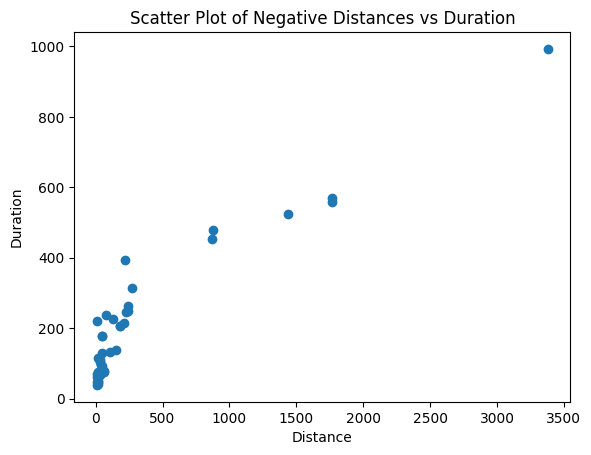

In [9]:
#checking the negative distances by plotting the abstract value with the duration

minus_distance_df=df[df['distance'] <0]
plt.scatter(minus_distance_df['distance'].abs(),minus_distance_df['duration'])

plt.xlabel('Distance')
plt.ylabel('Duration')
plt.title('Scatter Plot of Negative Distances vs Duration')

plt.show()

In [10]:
#filter out the all the data with distance>0

filtered_df = df[(df['distance'] >0)]
filtered_df.shape[0]


1478

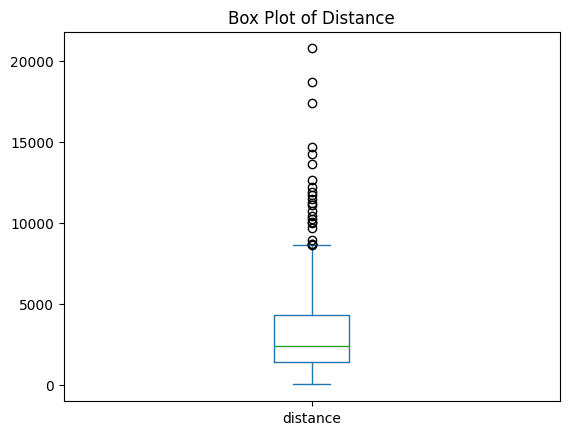

In [11]:
#creating a box plot for distance data

filtered_df['distance'].plot.box()
plt.title('Box Plot of Distance')
plt.show()

In [12]:
filtered_df[filtered_df['distance']>10000]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
214,single,1.75,6,PIRTTI,KYS,2054.0,10740,1,66.9,7.5
432,single,2.00,8,KAUPPAKATU,KAUPPAKATU,2391.0,12200,1,93.7,32.7
555,single,3.65,8,KEILANKANTA,KAUPPAKATU,4345.0,14240,1,140.6,31.8
705,single,3.55,6,PUIJONLAAKSO,PUIJONLAAKSO,4207.0,17410,1,144.9,56.4
866,single,1.70,7,SATAMA,PIRTTI,1992.0,11130,1,67.7,8.4
879,single,1.65,6,PIRTTI,KAUPPAKATU,1950.0,10040,1,47.9,9.3
1097,single,3.00,7,KAUPPAKATU,KAUPPAKATU,3545.0,13650,1,88.0,35.1
1175,single,1.75,8,PIRTTI,KAUPPAKATU,2091.0,10220,1,60.1,16.5
1202,single,4.10,8,NEULAMÄKI,NEULAMÄKI,4911.0,20770,1,124.2,52.2
1231,single,100.00,6,TASAVALLANKATU,PIRTTI,22793.0,14690,1,91.3,6.3


Keeping the above outliers in the distance, as they seem to be valid values. 

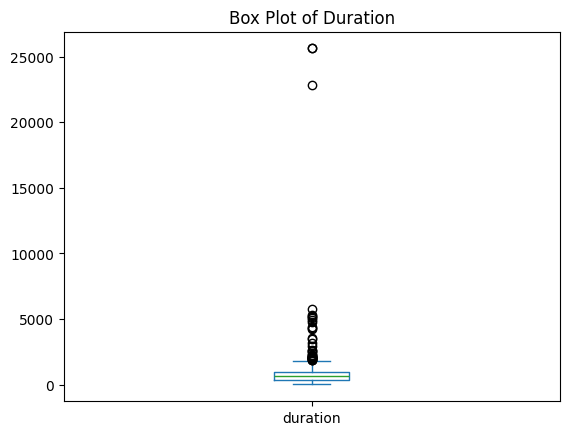

In [13]:
#creating a box plot for duration data

filtered_df['duration'].plot.box()
plt.title('Box Plot of Duration')
plt.show()


In [14]:
filtered_df[filtered_df['duration']>10000]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
100,savonia,100.0,9,NEULAMÄKI,MICROTEKNIA,25614.0,2310,0,0.0,3.6
609,savonia,100.0,9,NEULAMÄKI,MICROTEKNIA,25614.0,2310,0,0.0,3.6
1231,single,100.0,6,TASAVALLANKATU,PIRTTI,22793.0,14690,1,91.3,6.3


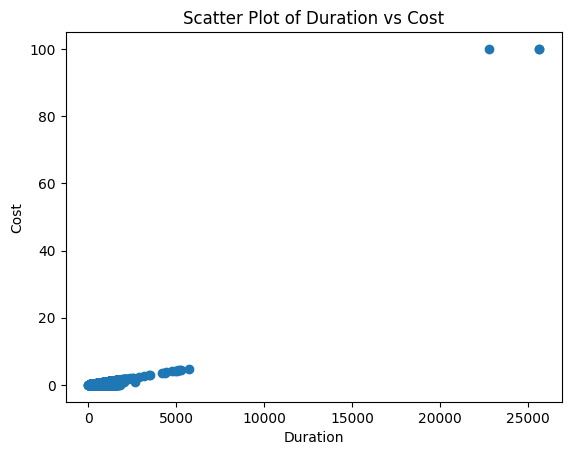

In [15]:
# Creating a scatter plot to explore the relationship between duration and cost

plt.scatter(filtered_df['duration'],filtered_df['cost'])

plt.xlabel('Duration')
plt.ylabel('Cost')
plt.title('Scatter Plot of Duration vs Cost')

plt.show()

In [16]:
filtered_df = filtered_df[(filtered_df['duration'] <10000)]

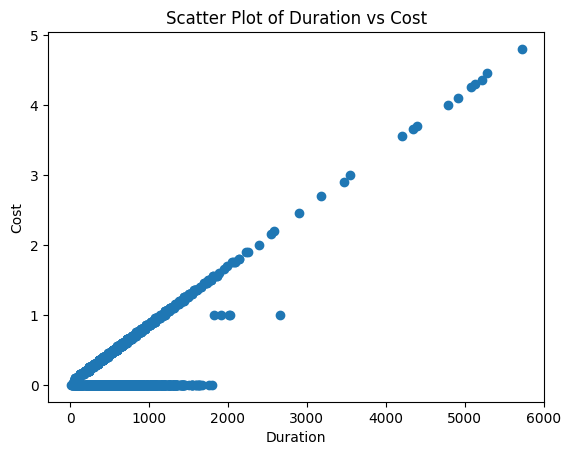

In [17]:
# Creating a scatter plot to explore the relationship between duration and cost

plt.scatter(filtered_df['duration'],filtered_df['cost'])

plt.xlabel('Duration')
plt.ylabel('Cost')
plt.title('Scatter Plot of Duration vs Cost')

plt.show()

#### Cost

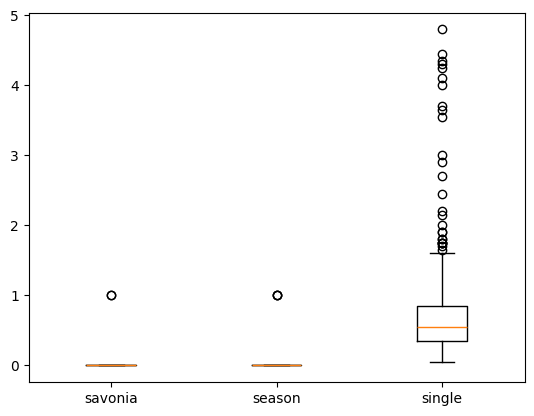

In [18]:
#creating a box plot to explore 'cost' variable values grouped by ticket type

grouped_by_ticket = filtered_df.groupby('ticket')
plt.boxplot([group['cost'] for _, group in grouped_by_ticket], labels=grouped_by_ticket.groups.keys())
plt.show()

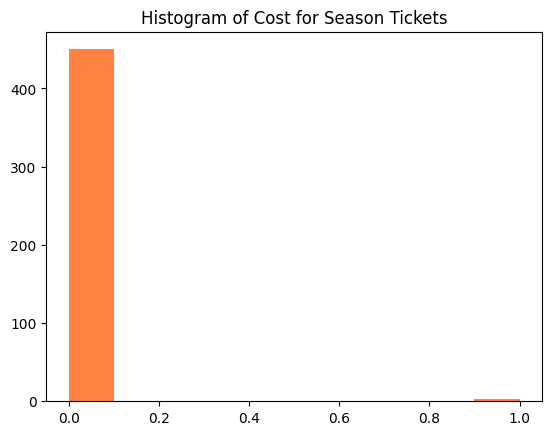

In [19]:
#Created a histogram of cost values for season ticket

plt.hist(filtered_df[filtered_df['ticket']=='season']['cost'],color='#ff8243')
plt.title('Histogram of Cost for Season Tickets')
plt.show()

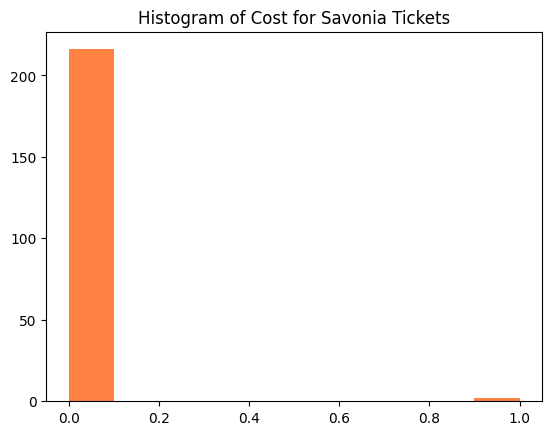

In [20]:
#Created a histogram of cost values for savonia ticket

plt.hist(filtered_df[filtered_df['ticket']=='savonia']['cost'],color='#ff8243')
plt.title('Histogram of Cost for Savonia Tickets')
plt.show()

In [21]:
#checking the outliers in savonia and season ticket types

filtered_df[(filtered_df['ticket'] != 'single') & (filtered_df['cost']>0)]


,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
251,season,1.0,6,KEILANKANTA,SATAMA,2021.0,7040,1,37.1,13.8
792,savonia,1.0,10,TORI,KAUPPAKATU,2011.0,4730,1,41.7,16.5
884,season,1.0,10,TASAVALLANKATU,TASAVALLANKATU,1918.0,7940,1,68.7,20.1
975,season,1.0,6,TORI,TORI,2660.0,4100,1,25.5,13.5
1569,savonia,1.0,10,TORI,TORI,1826.0,1590,0,0.0,2.7


In [22]:
transformed_df = filtered_df.copy()

In [23]:
transformed_df.loc[(transformed_df['cost'] >0)&(transformed_df['ticket']!='single'), 'cost'] = 0

In [24]:
transformed_df.loc[[251,792,884,975,1569]]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
251,season,0.0,6,KEILANKANTA,SATAMA,2021.0,7040,1,37.1,13.8
792,savonia,0.0,10,TORI,KAUPPAKATU,2011.0,4730,1,41.7,16.5
884,season,0.0,10,TASAVALLANKATU,TASAVALLANKATU,1918.0,7940,1,68.7,20.1
975,season,0.0,6,TORI,TORI,2660.0,4100,1,25.5,13.5
1569,savonia,0.0,10,TORI,TORI,1826.0,1590,0,0.0,2.7


#### Energy Used

In [25]:
asstance_check_false = (transformed_df['assistance']==0) & (transformed_df['energy_used']>0)
transformed_df[asstance_check_false]


,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
231,single,0.10,7,TASAVALLANKATU,TASAVALLANKATU,61.0,1300,0,9.0,11.1
611,season,0.00,10,PIRTTI,PIRTTI,1795.0,1880,0,12.1,2.7
1372,savonia,0.00,10,TORI,TORI,8.0,190,0,1.5,0.6
1453,single,0.55,7,TORI,PUIJONLAAKSO,611.0,2590,0,25.4,3.3


In [26]:
transformed_df.loc[(transformed_df['assistance']==0) & (transformed_df['energy_used']>0), 'assistance']=1

In [27]:
transformed_df.loc[[231,611,1372,1453]]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
231,single,0.10,7,TASAVALLANKATU,TASAVALLANKATU,61.0,1300,1,9.0,11.1
611,season,0.00,10,PIRTTI,PIRTTI,1795.0,1880,1,12.1,2.7
1372,savonia,0.00,10,TORI,TORI,8.0,190,1,1.5,0.6
1453,single,0.55,7,TORI,PUIJONLAAKSO,611.0,2590,1,25.4,3.3


In [28]:
asstance_check_true = (transformed_df['assistance']==1) & (transformed_df['energy_used']==0)
transformed_df[asstance_check_true]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
193,single,0.10,7,NEULAMÄKI,NEULAMÄKI,101.0,10,1,0.0,0.0
254,single,0.10,7,PUIJONLAAKSO,PUIJONLAAKSO,66.0,30,1,0.0,0.0
321,savonia,0.00,9,TORI,TORI,112.0,130,1,0.0,0.0
375,single,0.05,7,TORI,TORI,57.0,10,1,0.0,0.0
507,single,0.05,6,SATAMA,SATAMA,59.0,80,1,0.0,0.0
940,season,0.00,6,TASAVALLANKATU,TASAVALLANKATU,67.0,10,1,0.0,0.0
956,single,1.05,6,TORI,PUIJONLAAKSO,1214.0,10,1,0.0,0.0
1027,season,0.00,9,KEILANKANTA,KEILANKANTA,74.0,10,1,0.0,0.0
1049,season,0.00,6,TORI,TORI,197.0,60,1,0.0,0.0
1102,single,1.20,9,KEILANKANTA,TASAVALLANKATU,1408.0,4400,1,0.0,0.0


In [29]:
transformed_df.loc[(transformed_df['assistance']==1) & (transformed_df['energy_used']==0), 'assistance']=0

In [30]:
transformed_df.loc[[193,254,1102]]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
193,single,0.1,7,NEULAMÄKI,NEULAMÄKI,101.0,10,0,0.0,0.0
254,single,0.1,7,PUIJONLAAKSO,PUIJONLAAKSO,66.0,30,0,0.0,0.0
1102,single,1.2,9,KEILANKANTA,TASAVALLANKATU,1408.0,4400,0,0.0,0.0


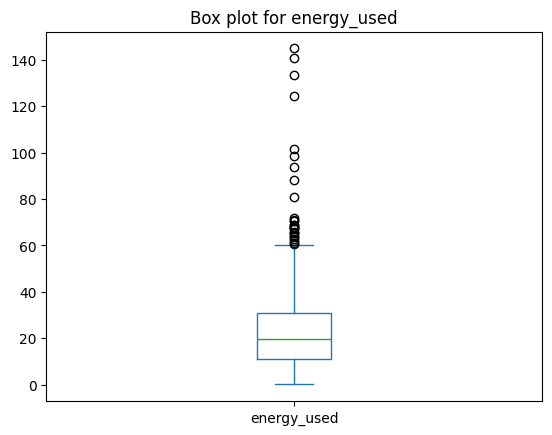

In [31]:
#creating a box plot for energy_used

transformed_df[transformed_df['assistance']==1]['energy_used'].plot.box()
plt.title('Box plot for energy_used')
plt.show()

In [32]:
transformed_df[transformed_df['energy_used']>120]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
555,single,3.65,8,KEILANKANTA,KAUPPAKATU,4345.0,14240,1,140.6,31.8
705,single,3.55,6,PUIJONLAAKSO,PUIJONLAAKSO,4207.0,17410,1,144.9,56.4
1202,single,4.10,8,NEULAMÄKI,NEULAMÄKI,4911.0,20770,1,124.2,52.2
1759,single,4.30,5,KEILANKANTA,KEILANKANTA,5136.0,18720,1,133.4,22.2


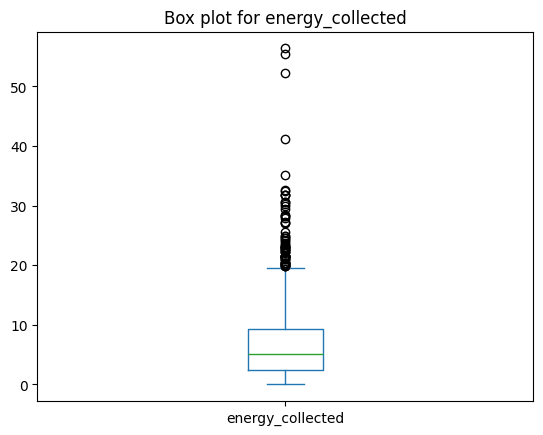

In [33]:
#creating a box plot for energy_collected

transformed_df['energy_collected'].plot.box()
plt.title('Box plot for energy_collected')
plt.show()

In [34]:
transformed_df[transformed_df['energy_collected']>40]

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
705,single,3.55,6,PUIJONLAAKSO,PUIJONLAAKSO,4207.0,17410,1,144.9,56.4
1202,single,4.10,8,NEULAMÄKI,NEULAMÄKI,4911.0,20770,1,124.2,52.2
1571,single,1.50,7,NEULAMÄKI,SATAMA,1782.0,6510,1,38.1,41.1
1649,single,4.00,5,TORI,TORI,4793.0,11200,1,98.3,55.5


In [35]:
duplicates = transformed_df[transformed_df.duplicated(keep=False)]
duplicates.sort_values(by='duration')

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
228,savonia,0.00,10,TORI,KAUPPAKATU,111.0,390,0,0.0,0.6
1392,savonia,0.00,10,TORI,KAUPPAKATU,111.0,390,0,0.0,0.6
460,savonia,0.00,9,NEULAMÄKI,MICROTEKNIA,250.0,1400,0,0.0,6.9
887,savonia,0.00,9,NEULAMÄKI,MICROTEKNIA,250.0,1400,0,0.0,6.9
445,season,0.00,5,KAUPPAKATU,TASAVALLANKATU,351.0,1610,1,11.9,2.7
626,season,0.00,5,KAUPPAKATU,TASAVALLANKATU,351.0,1610,1,11.9,2.7
1056,single,0.35,7,PUIJONLAAKSO,MICROTEKNIA,410.0,2140,1,12.5,20.4
1623,single,0.35,7,PUIJONLAAKSO,MICROTEKNIA,410.0,2140,1,12.5,20.4
737,single,0.75,7,SATAMA,PUIJONLAAKSO,887.0,3360,1,45.0,5.7
823,single,0.75,7,SATAMA,PUIJONLAAKSO,887.0,3360,1,45.0,5.7


In [36]:
transformed_df.reset_index()

,index,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected
0,0,single,0.35,9,MICROTEKNIA,PUIJONLAAKSO,411.0,2150,1,19.0,2.7
1,1,single,1.20,5,SATAMA,KEILANKANTA,1411.0,7130,1,53.8,15.3
2,2,savonia,0.00,9,TASAVALLANKATU,NEULAMÄKI,1308.0,5420,1,43.0,9.9
3,3,savonia,0.00,10,TORI,KAUPPAKATU,1036.0,1180,1,6.5,2.1
4,4,single,0.30,9,TORI,TORI,319.0,1120,1,13.7,1.2
...,...,...,...,...,...,...,...,...,...,...,...
1470,1768,single,1.00,7,KEILANKANTA,KAUPPAKATU,1167.0,6070,1,34.3,3.0
1471,1769,savonia,0.00,10,KAUPPAKATU,TORI,836.0,960,1,8.0,2.7
1472,1770,single,0.20,7,TORI,SATAMA,199.0,930,1,3.7,3.6
1473,1772,savonia,0.00,9,MICROTEKNIA,PUIJONLAAKSO,610.0,2460,1,36.5,6.9


In [37]:
transformed_df.shape[0]

1475

#### Data Exploration

In [38]:
# Number of trips made

transformed_df.groupby('ticket')['ticket'].count().to_frame().rename(columns={'ticket': 'Number of Trips'})


,Number of Trips
ticket,
savonia,218
season,453
single,804


In [39]:
# Total distance traveled, time and total fees paid

transformed_df.groupby('ticket')[['distance','duration']].sum()


,distance,duration
ticket,,
savonia,494630,137753.0
season,1311590,314730.0
single,2551610,633204.0


In [40]:
# Mean distance traveled, time and total fees paid

transformed_df.groupby('ticket')[['distance','duration']].mean()

,distance,duration
ticket,,
savonia,2268.944954,631.894495
season,2895.342163,694.768212
single,3173.644279,787.567164


In [41]:
# Total distance traveled, time and total fees paid

transformed_df.groupby('ticket')[['cost']].sum()


,cost
ticket,
savonia,0.00
season,0.00
single,548.25


For each ticket type, visualise the monthly rental activity in terms of the total distance travelled. Examine your results and make comments about the development of the rental activity over time.

The logistics team transported bikes between renting stations in order to balance their availability, but they struggled to maintain a decent number of bikes available at each station. To optimise the transport operation, the logistics team needs to know which stations tend to get depleted of bikes and which stations tend to accumulate bikes. While transporting bikes, they also noticed that quite often the bikes had fully discharged batteries. We need to upgrade our charging stations to keep them charged. For that, we need to know how much battery levels tend to change during trips.

In [42]:
result=transformed_df.groupby(['ticket','month'])[['distance']].sum()

In [43]:
result

distance
ticket  month          
savonia 9        239880
        10       254750
season  4         30680
        5        258330
        6        244780
        7        268150
        8        214490
        9        184840
        10       110320
single  4         34290
        5        494500
        6        695550
        7        594890
        8        357890
        9        240370
        10       134120

In [44]:
#replacing month numbers with month names

months = {4: 'April', 5: 'May', 6: 'June',7:'July',8:'August',9:'September',10:'October'}
result.index = result.index.set_levels(result.index.levels[1].map(months), level=1)


In [45]:
result

distance
ticket  month              
savonia September    239880
        October      254750
season  April         30680
        May          258330
        June         244780
        July         268150
        August       214490
        September    184840
        October      110320
single  April         34290
        May          494500
        June         695550
        July         594890
        August       357890
        September    240370
        October      134120

In [46]:
#create pivot table 

pivot_table = result.pivot_table(values='distance', index='ticket', columns='month')

In [47]:
#pivot_table

In [48]:
#re-order months

month_order = ['April','May','June','July','August','September','October']
pivot_table = pivot_table.reindex(columns=month_order)


In [49]:
pivot_table

month,April,May,June,July,August,September,October
ticket,,,,,,,
savonia,NaN,NaN,NaN,NaN,NaN,239880.0,254750.0
season,30680.0,258330.0,244780.0,268150.0,214490.0,184840.0,110320.0
single,34290.0,494500.0,695550.0,594890.0,357890.0,240370.0,134120.0


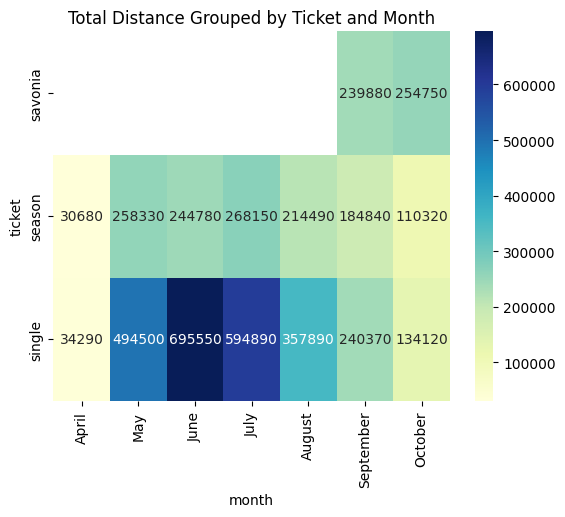

In [50]:
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Total Distance Grouped by Ticket and Month')
plt.show()

In [51]:
pivot_table

month,April,May,June,July,August,September,October
ticket,,,,,,,
savonia,NaN,NaN,NaN,NaN,NaN,239880.0,254750.0
season,30680.0,258330.0,244780.0,268150.0,214490.0,184840.0,110320.0
single,34290.0,494500.0,695550.0,594890.0,357890.0,240370.0,134120.0


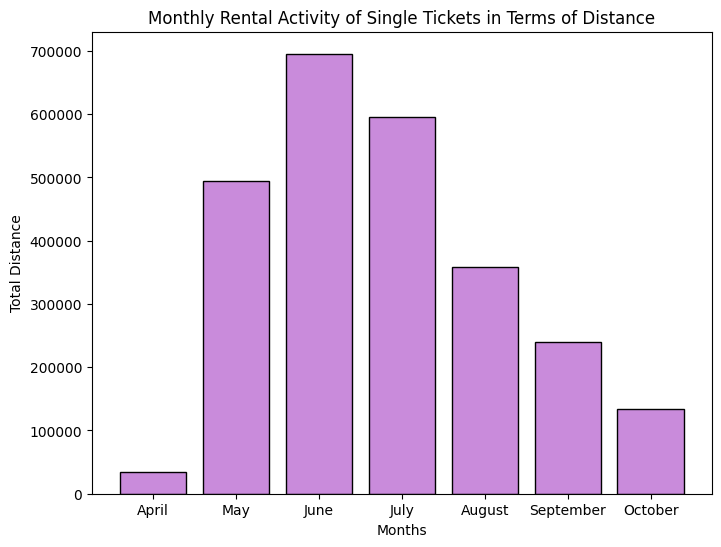

In [52]:
# Create a bar plot for the Monthly Rental Activity of Single Ticket in Terms of Distance
months=['April','May','June','July','August','September','October']
plt.figure(figsize=(8, 6)) 

plt.bar(months, result.loc['single','distance'],edgecolor='black', color='#c98bdb')
plt.xlabel('Months')
plt.ylabel('Total Distance')
plt.title('Monthly Rental Activity of Single Tickets in Terms of Distance')

plt.show()

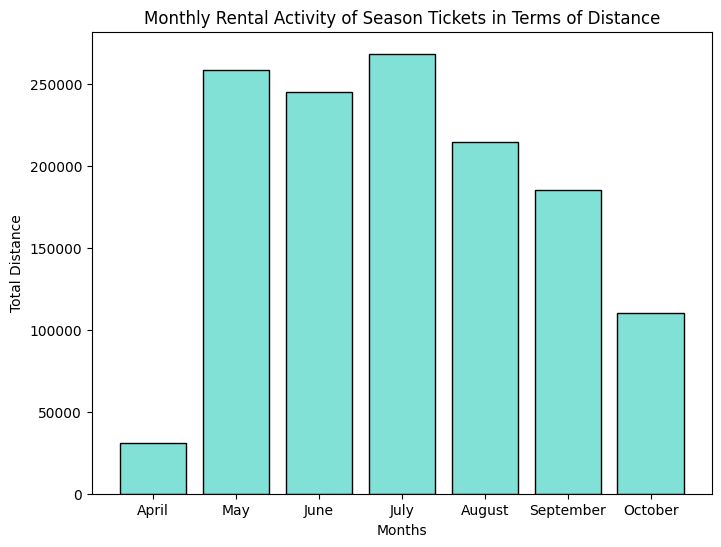

In [53]:
# Create a bar plot for the Monthly Rental Activity of Single Ticket in Terms of Distance
months=['April','May','June','July','August','September','October']
plt.figure(figsize=(8, 6)) 

plt.bar(months, result.loc['season','distance'],edgecolor='black', color='#82e1d7')
plt.xlabel('Months')
plt.ylabel('Total Distance')
plt.title('Monthly Rental Activity of Season Tickets in Terms of Distance')

plt.show()

# 2

In [54]:
trips_started=transformed_df.groupby(['location_from'])['ticket'].count().rename('Number of Trips Started')
trips_ended=transformed_df.groupby(['location_to'])['ticket'].count().rename('Number of Trips Ended')

In [55]:
trips_started

location_from
KAUPPAKATU        194
KEILANKANTA       130
KYS                80
MICROTEKNIA       157
NEULAMÄKI         144
PIRTTI             25
PUIJONLAAKSO      134
SATAMA            167
TASAVALLANKATU    111
TORI              333
Name: Number of Trips Started, dtype: int64

In [56]:
trips_ended

location_to
KAUPPAKATU        236
KEILANKANTA       120
KYS                63
MICROTEKNIA       149
NEULAMÄKI         144
PIRTTI             26
PUIJONLAAKSO      164
SATAMA            128
TASAVALLANKATU    125
TORI              320
Name: Number of Trips Ended, dtype: int64

In [57]:
locations= sorted(transformed_df['location_from'].unique())
locations

['KAUPPAKATU',
 'KEILANKANTA',
 'KYS',
 'MICROTEKNIA',
 'NEULAMÄKI',
 'PIRTTI',
 'PUIJONLAAKSO',
 'SATAMA',
 'TASAVALLANKATU',
 'TORI']

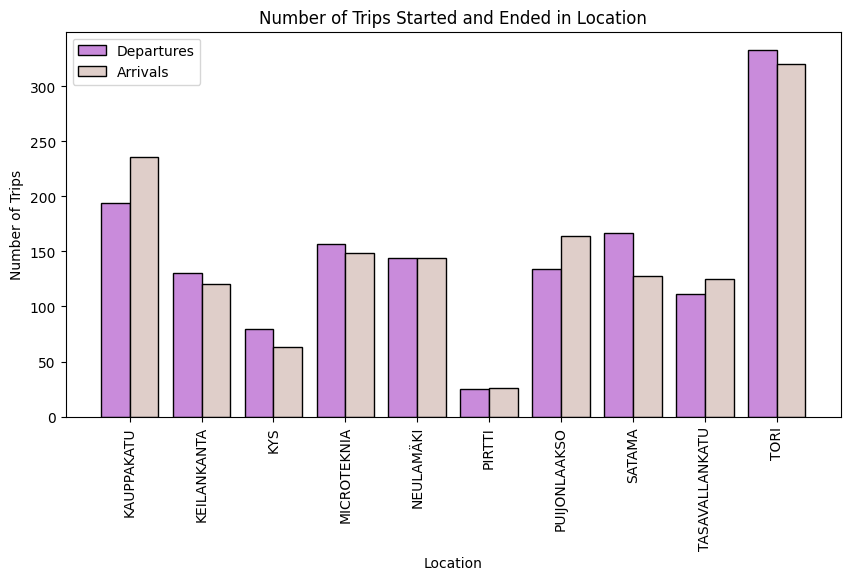

In [58]:
plt.figure(figsize=(10, 5))

r= np.arange(10)

plt.bar(r, trips_started,0.4,color='#c98bdb',edgecolor='black')
plt.bar(r+0.4, trips_ended,0.4,color='#dfcec9',edgecolor='black')

plt.xlabel('Location')
plt.ylabel('Number of Trips')
plt.title('Number of Trips Started and Ended in Location')
plt.legend(['Departures', 'Arrivals'])

plt.xticks(r+0.2, trips_started.index,rotation=90) 

plt.show()


In [59]:
(trips_ended-trips_started).rename('Difference').to_frame()

,Difference
location_to,
KAUPPAKATU,42
KEILANKANTA,-10
KYS,-17
MICROTEKNIA,-8
NEULAMÄKI,0
PIRTTI,1
PUIJONLAAKSO,30
SATAMA,-39
TASAVALLANKATU,14


In [60]:
#Create new column 'net_energy_gain'
transformed_df['net_energy_gain']=transformed_df['energy_collected']-transformed_df['energy_used']


In [61]:
transformed_df.head(5)

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected,net_energy_gain
0,single,0.35,9,MICROTEKNIA,PUIJONLAAKSO,411.0,2150,1,19.0,2.7,-16.3
1,single,1.20,5,SATAMA,KEILANKANTA,1411.0,7130,1,53.8,15.3,-38.5
2,savonia,0.00,9,TASAVALLANKATU,NEULAMÄKI,1308.0,5420,1,43.0,9.9,-33.1
3,savonia,0.00,10,TORI,KAUPPAKATU,1036.0,1180,1,6.5,2.1,-4.4
4,single,0.30,9,TORI,TORI,319.0,1120,1,13.7,1.2,-12.5


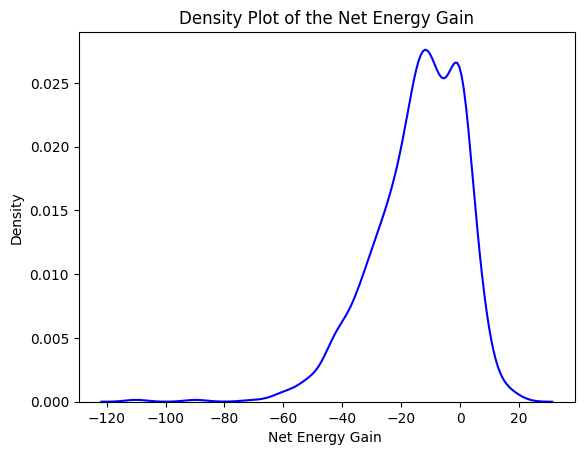

In [62]:
sns.kdeplot(transformed_df['net_energy_gain'], color='blue')
plt.title('Density Plot of the Net Energy Gain')
plt.xlabel('Net Energy Gain ')
plt.ylabel('Density')

plt.show()

In [63]:
transformed_df['net_energy_gain'].mean()

-14.08291525423729

# Hypothesis 1

Hypothesis- Trip durations tend to be different between the customers who have a season ticket
and the customers who buy single tickets.


In [64]:
#seperating duration data on season tickets and single tickets

group_season = transformed_df[transformed_df['ticket'] == 'season']['duration']
group_single = transformed_df[transformed_df['ticket'] == 'single']['duration']



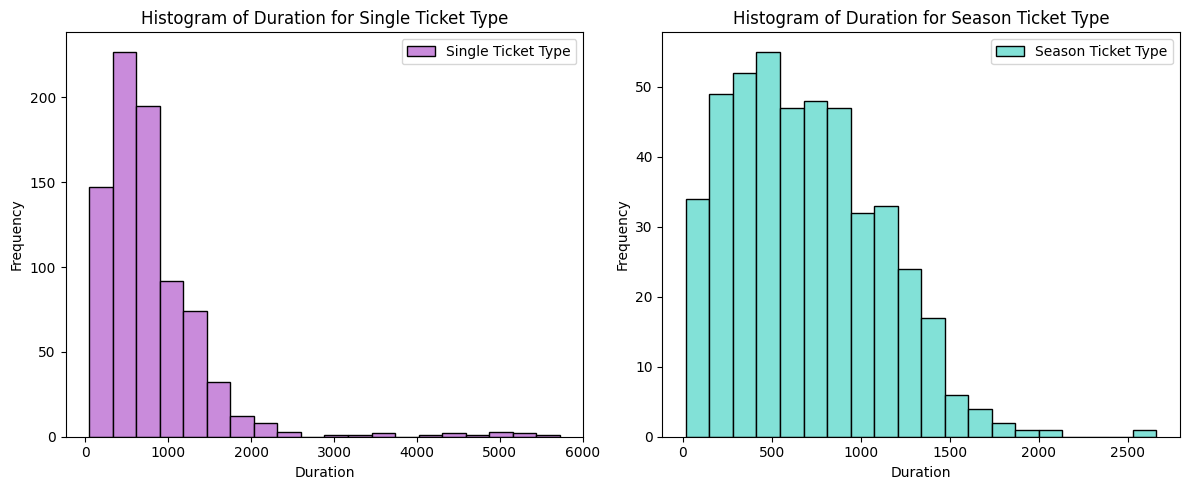

In [65]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

#Create Histogram for duration for single ticket type

plt.hist(group_single, bins=20, label='Single Ticket Type',edgecolor='black', color='#c98bdb')

plt.legend()
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of Duration for Single Ticket Type')

plt.subplot(1, 2, 2)

#Create Histogram for duration for season ticket type

plt.hist(group_season, bins=20, label='Season Ticket Type',edgecolor='black', color='#82e1d7')

plt.legend()
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of Duration for Season Ticket Type')

plt.tight_layout()
plt.show()

In [66]:
print(stat.mannwhitneyu(group_season, group_single, use_continuity=True).pvalue, end="\n\n")

0.2885827017890521



p_value is greater than 0.05. So there's no strong statisticaal evidence to prove against the null hypothesis. 

# Hypothesis 2

Hypothesis - Travel distance positively correlates with the average rate at which electricity is
consumed during the trip.


In [67]:
transformed_df['energy_consumption_rate']=transformed_df['energy_used']/transformed_df['duration']

In [68]:
transformed_df.head(5)

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected,net_energy_gain,energy_consumption_rate
0,single,0.35,9,MICROTEKNIA,PUIJONLAAKSO,411.0,2150,1,19.0,2.7,-16.3,0.046229
1,single,1.20,5,SATAMA,KEILANKANTA,1411.0,7130,1,53.8,15.3,-38.5,0.038129
2,savonia,0.00,9,TASAVALLANKATU,NEULAMÄKI,1308.0,5420,1,43.0,9.9,-33.1,0.032875
3,savonia,0.00,10,TORI,KAUPPAKATU,1036.0,1180,1,6.5,2.1,-4.4,0.006274
4,single,0.30,9,TORI,TORI,319.0,1120,1,13.7,1.2,-12.5,0.042947


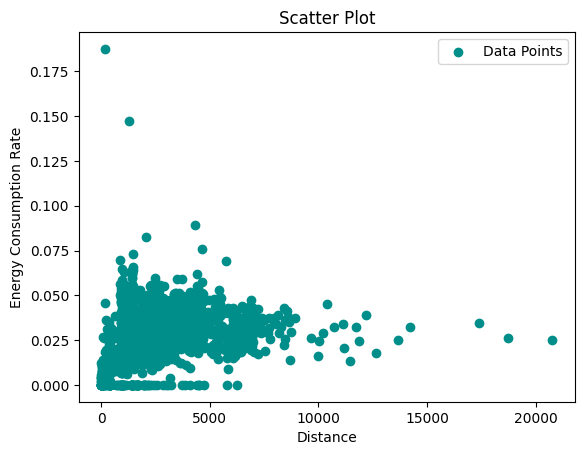

In [69]:
plt.scatter(transformed_df['distance'], transformed_df['energy_consumption_rate'], label='Data Points', c='#008e8a', marker='o')

plt.xlabel('Distance')
plt.ylabel('Energy Consumption Rate')
plt.title('Scatter Plot')
plt.legend()

plt.show()

In [70]:
print(stat.shapiro(transformed_df['distance']).pvalue, end="\n\n")

1.254139330996114e-32



In [71]:
print(stat.shapiro(transformed_df['energy_consumption_rate']).pvalue, end="\n\n")

7.391108005875698e-25



In [72]:
print(tuple(stat.spearmanr(transformed_df['distance'], transformed_df['energy_consumption_rate'])), end="\n\n")


(0.3052330582858624, 3.540820213825516e-33)



has a positive but not a strong correlation. with the small value in the p value, the correlation is statistically significant.

# Hypothesis 3

Hypothesis- savonia ticket type differs from the others with respect to how often the electric
assistance is used.


In [73]:
transformed_df['new_ticket_type'] = np.where(transformed_df['ticket'] == 'savonia', 'savonia', 'other')
transformed_df.head(5)

,ticket,cost,month,location_from,location_to,duration,distance,assistance,energy_used,energy_collected,net_energy_gain,energy_consumption_rate,new_ticket_type
0,single,0.35,9,MICROTEKNIA,PUIJONLAAKSO,411.0,2150,1,19.0,2.7,-16.3,0.046229,other
1,single,1.20,5,SATAMA,KEILANKANTA,1411.0,7130,1,53.8,15.3,-38.5,0.038129,other
2,savonia,0.00,9,TASAVALLANKATU,NEULAMÄKI,1308.0,5420,1,43.0,9.9,-33.1,0.032875,savonia
3,savonia,0.00,10,TORI,KAUPPAKATU,1036.0,1180,1,6.5,2.1,-4.4,0.006274,savonia
4,single,0.30,9,TORI,TORI,319.0,1120,1,13.7,1.2,-12.5,0.042947,other


In [74]:
contingency_table = pd.crosstab(transformed_df['new_ticket_type'], transformed_df['assistance'])

In [75]:
contingency_table

assistance,0,1
new_ticket_type,,
other,76,1181
savonia,30,188


In [76]:
p_value= stat.chi2_contingency(contingency_table)[1]
chi2, p, dof, expected =  stat.chi2_contingency(contingency_table)

print("P-value:", p)


P-value: 8.501342153935647e-05


In [77]:
print("Expected Frequencies Table:")

pd.DataFrame(expected, index=['other','savonia'])

Expected Frequencies Table:


,0,1
other,90.333559,1166.666441
savonia,15.666441,202.333559


In [78]:
contingency_table = pd.crosstab(transformed_df['ticket'], transformed_df['assistance'])

In [79]:
print(contingency_table)

assistance   0    1
ticket             
savonia     30  188
season      21  432
single      55  749


In [80]:
p_value= stat.chi2_contingency(contingency_table)[1]
chi2, p, dof, expected =  stat.chi2_contingency(contingency_table)

# Output
print("Chi-Squared Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies Table:")
print(expected)


Chi-Squared Statistic: 18.692093013087504
P-value: 8.730991684580399e-05
Degrees of Freedom: 2
Expected Frequencies Table:
[[ 15.66644068 202.33355932]
 [ 32.55457627 420.44542373]
 [ 57.77898305 746.22101695]]
